## Exploratory Data Analysis - Practical 1, MTech Data Science - 24MCD002

In [1]:
import pandas as pd

df = pd.read_csv('WHR2024.csv')

## MatplotLib

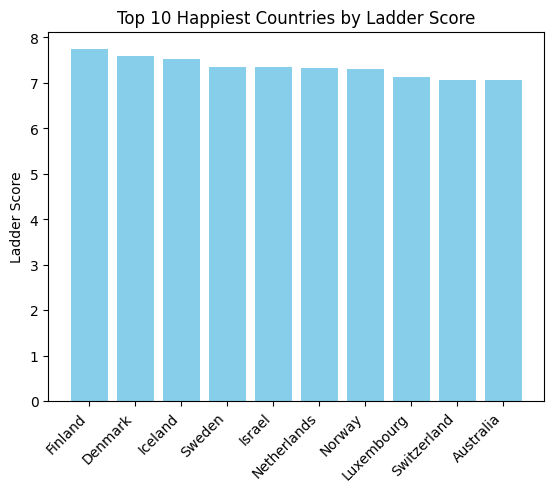

In [2]:
import matplotlib.pyplot as plt

#Sort and get the top 10 countries
top_10 = df.sort_values(by="Ladder score", ascending=False).head(10)
plt.bar(top_10["Country name"], top_10["Ladder score"], color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Happiest Countries by Ladder Score")
plt.ylabel("Ladder Score")
plt.show()


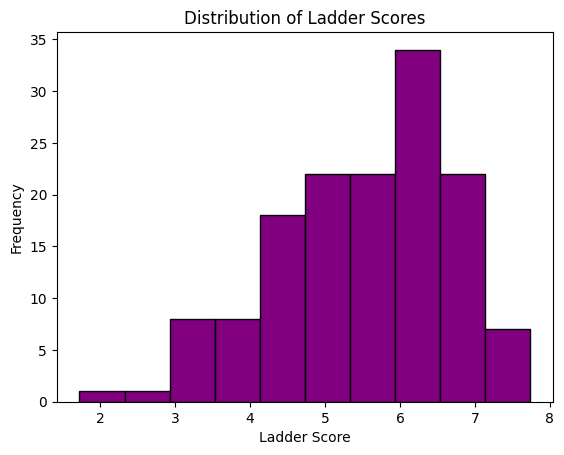

In [3]:
#histogram
plt.hist(df["Ladder score"], bins=10, color="purple", edgecolor="black")
plt.title("Distribution of Ladder Scores")
plt.xlabel("Ladder Score")
plt.ylabel("Frequency")
plt.show()

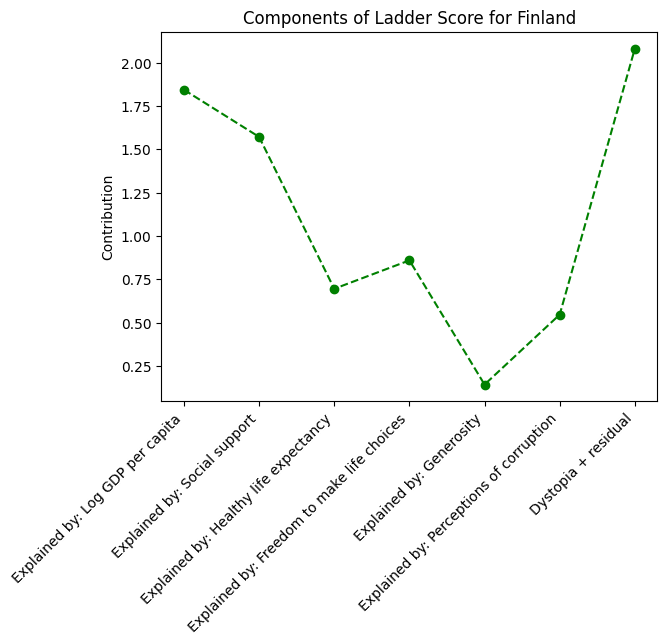

In [4]:
#Example for Finland - linegraph
finland = df[df["Country name"] == "Finland"]
components = [
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption",
    "Dystopia + residual"
]
values = finland[components].values.flatten()

plt.plot(components, values, marker="o", linestyle="--", color="green")
plt.xticks(rotation=45, ha="right")
plt.title("Components of Ladder Score for Finland")
plt.ylabel("Contribution")
plt.show()


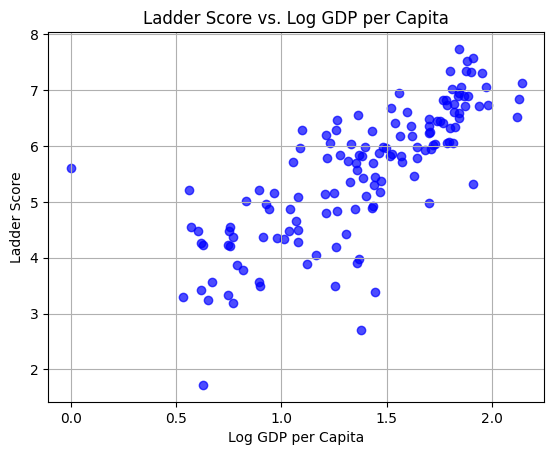

In [5]:
#scatter plot
plt.scatter(df["Explained by: Log GDP per capita"], df["Ladder score"], color="blue", alpha=0.7)
plt.title("Ladder Score vs. Log GDP per Capita")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Ladder Score")
plt.grid()
plt.show()


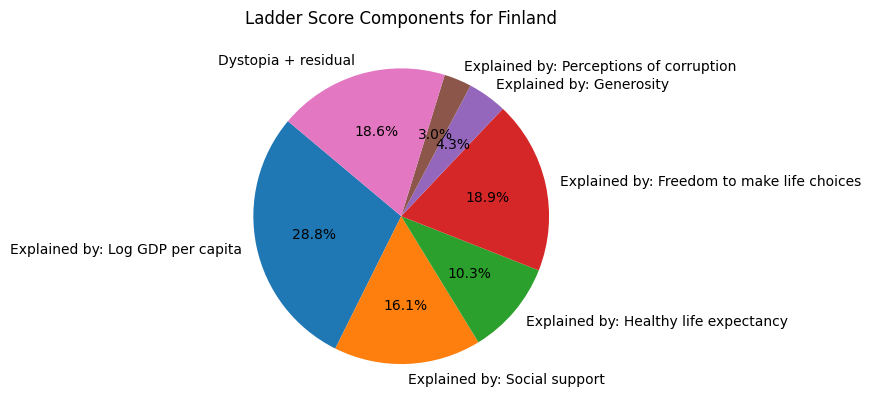

In [6]:
#pie chart
#For India
india = df[df["Country name"] == "India"].iloc[0]
components = [
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption",
    "Dystopia + residual"
]
values = india[components]

plt.pie(values, labels=components, autopct="%1.1f%%", startangle=140)
plt.title("Ladder Score Components for Finland")
plt.show()


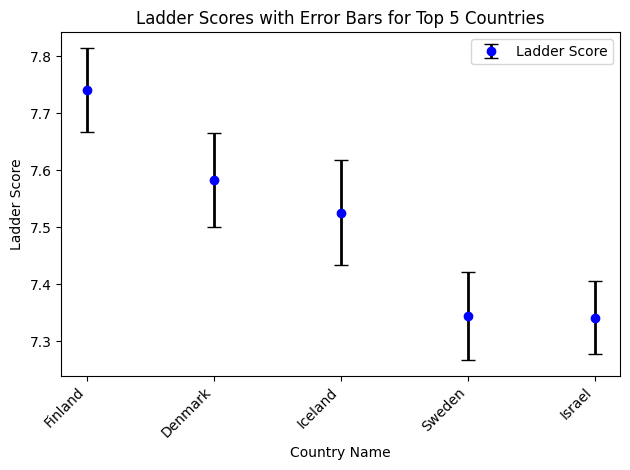

In [8]:
#error bar plot
#get the top 5 countries by Ladder Score
top_5 = df.sort_values(by="Ladder score", ascending=False).head(5)

#calculate the error margins (upper and lower whiskers)
yerr = [
    top_5["Ladder score"] - top_5["lowerwhisker"],  # Lower error
    top_5["upperwhisker"] - top_5["Ladder score"]   # Upper error
]

#create the error bar plot
plt.errorbar(
    top_5["Country name"], 
    top_5["Ladder score"], 
    yerr=yerr, 
    fmt="o", 
    color="blue", 
    ecolor="black", 
    elinewidth=2, 
    capsize=5, 
    label="Ladder Score"
)

# Add labels and title
plt.title("Ladder Scores with Error Bars for Top 5 Countries")
plt.ylabel("Ladder Score")
plt.xlabel("Country Name")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

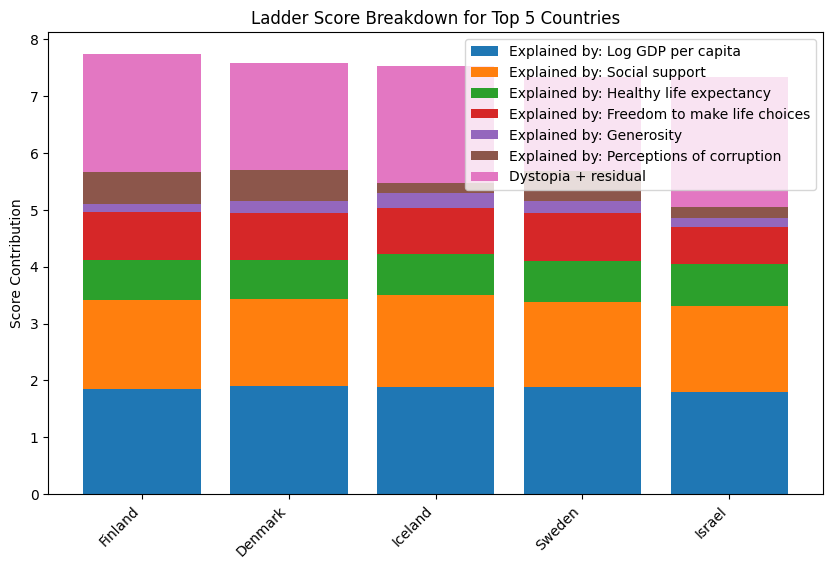

In [9]:
top_5 = df.sort_values(by="Ladder score", ascending=False).head(5)
components = [
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption",
    "Dystopia + residual"
]

#Stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bottom = None
for component in components:
    if bottom is None:
        bottom = top_5[component]
        ax.bar(top_5["Country name"], top_5[component], label=component)
    else:
        ax.bar(top_5["Country name"], top_5[component], bottom=bottom, label=component)
        bottom += top_5[component]

ax.set_title("Ladder Score Breakdown for Top 5 Countries")
ax.set_ylabel("Score Contribution")
ax.legend(loc="upper right")
plt.xticks(rotation=45, ha="right")
plt.show()


## Seaborn

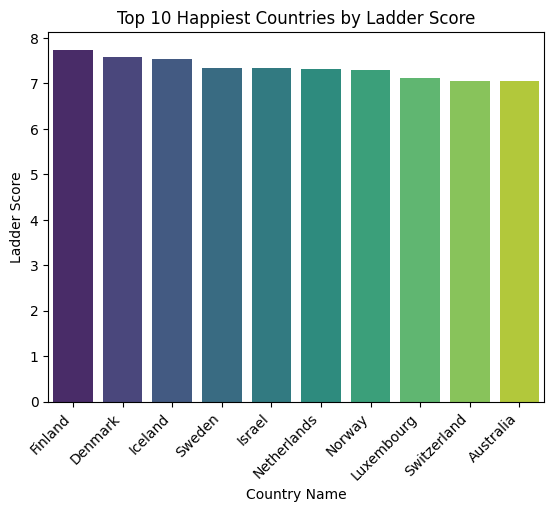

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

#Sort and select the top 10 countries
top_10 = df.sort_values(by="Ladder score", ascending=False).head(10)

#Create the bar plot
sns.barplot(x="Country name", y="Ladder score", data=top_10, palette="viridis")
plt.title("Top 10 Happiest Countries by Ladder Score")
plt.ylabel("Ladder Score")
plt.xlabel("Country Name")
plt.xticks(rotation=45, ha="right")
plt.show()


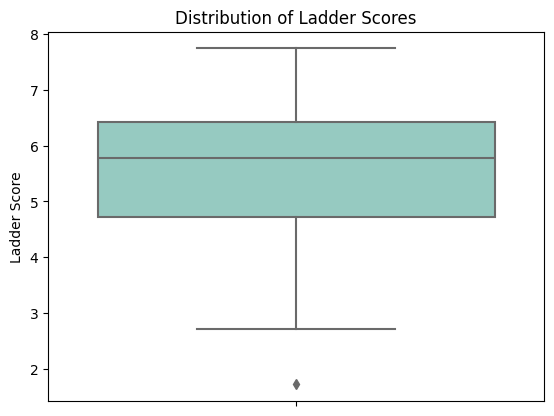

In [11]:
#boxplot

# sns.boxplot(x="Region", y="Ladder score", data=df, palette="Set2")
# plt.title("Distribution of Ladder Scores by Region")
# plt.ylabel("Ladder Score")
# plt.xlabel("Region")
# plt.xticks(rotation=45, ha="right")
# plt.show()

#create a box plot for Ladder Score
sns.boxplot(y="Ladder score", data=df, palette="Set3")
plt.title("Distribution of Ladder Scores")
plt.ylabel("Ladder Score")
plt.show()

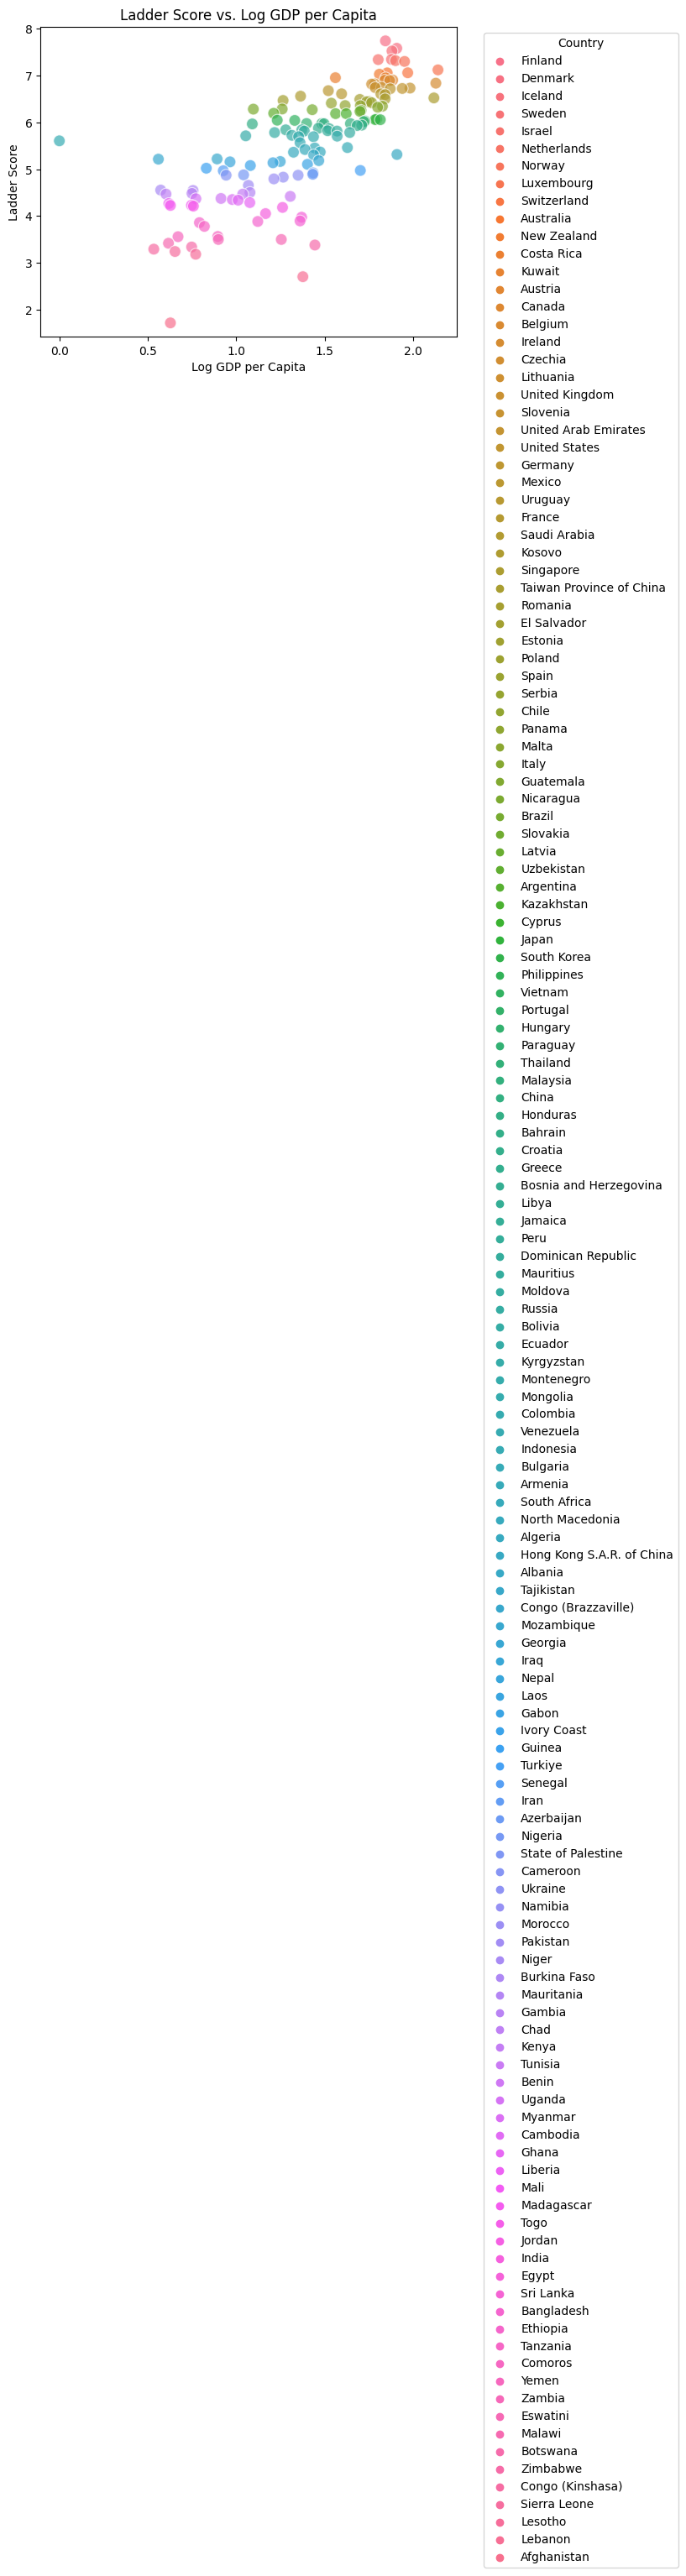

In [12]:
#scatterplot
sns.scatterplot(
    x="Explained by: Log GDP per capita", 
    y="Ladder score", 
    data=df, 
    hue="Country name", 
    palette="husl", 
    s=100, alpha=0.7
)
plt.title("Ladder Score vs. Log GDP per Capita")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Ladder Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Country")
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

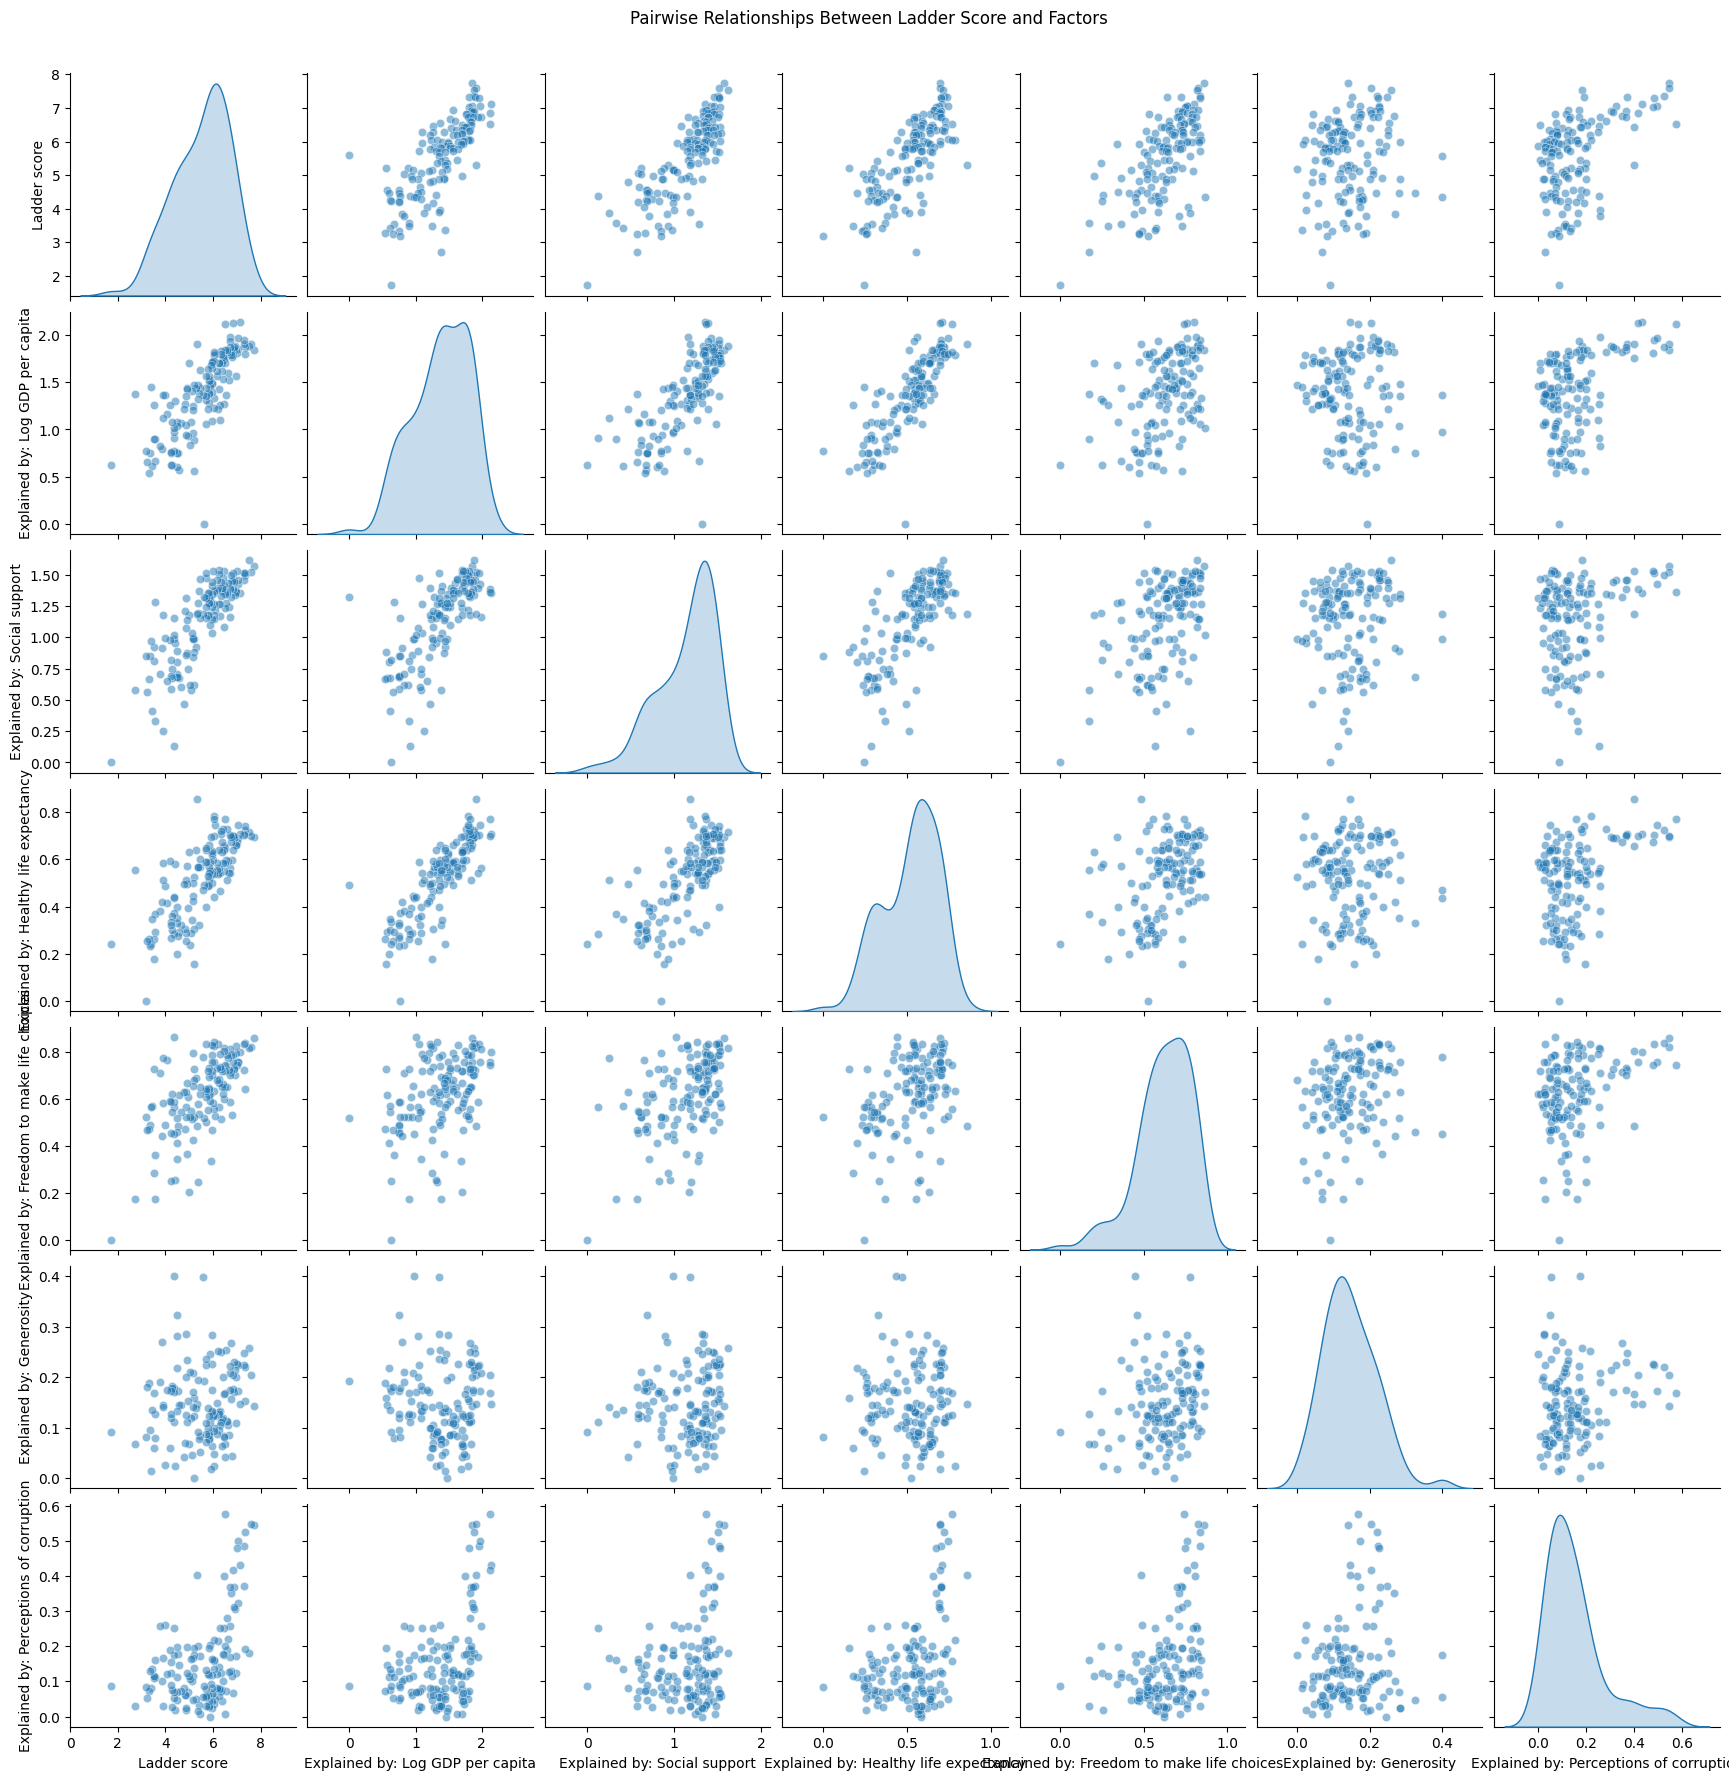

In [13]:
#Pair Plot
factors = [
    "Ladder score",
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption"
]
sns.pairplot(df[factors], diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Pairwise Relationships Between Ladder Score and Factors", y=1.02)
plt.show()


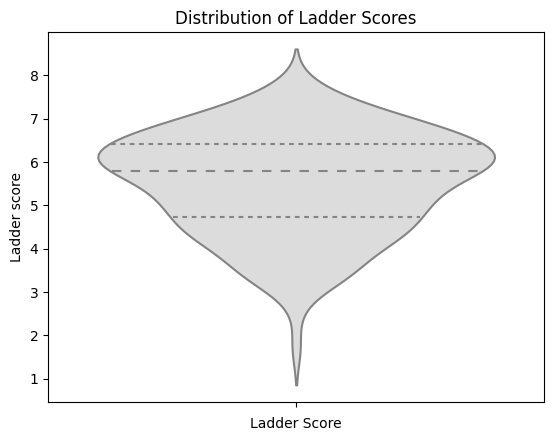

In [14]:
#Violin plot
sns.violinplot(y="Ladder score", data=df, inner="quartile", palette="coolwarm")
plt.title("Distribution of Ladder Scores")
plt.xlabel("Ladder Score")
plt.show()


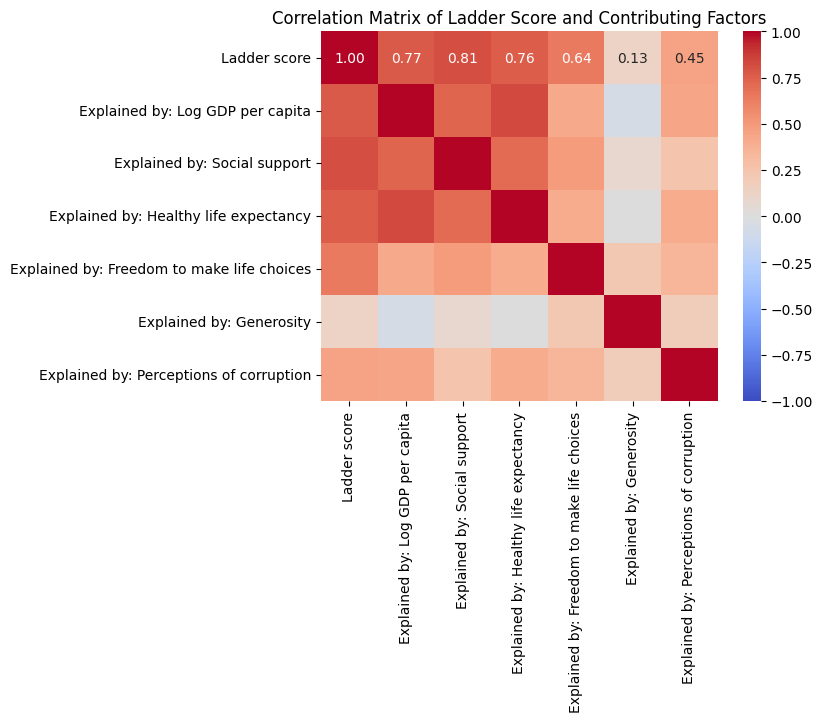

In [15]:
import numpy as np

#correlation matrix
corr = df[
    [
        "Ladder score",
        "Explained by: Log GDP per capita",
        "Explained by: Social support",
        "Explained by: Healthy life expectancy",
        "Explained by: Freedom to make life choices",
        "Explained by: Generosity",
        "Explained by: Perceptions of corruption"
    ]
].corr()

#create a heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Ladder Score and Contributing Factors")
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


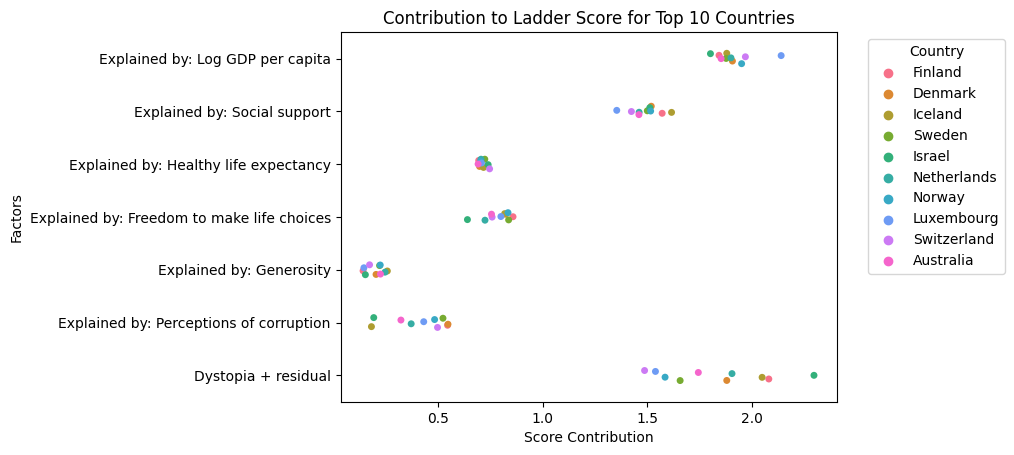

In [16]:
#Strip plot

#Sort and get the top 10 countries
top_10 = df.sort_values(by="Ladder score", ascending=False).head(10)

#melt data for long-format plotting
melted_data = top_10.melt(
    id_vars=["Country name"], 
    value_vars=[
        "Explained by: Log GDP per capita",
        "Explained by: Social support",
        "Explained by: Healthy life expectancy",
        "Explained by: Freedom to make life choices",
        "Explained by: Generosity",
        "Explained by: Perceptions of corruption",
        "Dystopia + residual"
    ],
    var_name="Factors",
    value_name="Score Contribution"
)

#create strip plot
sns.stripplot(
    x="Score Contribution", 
    y="Factors", 
    hue="Country name", 
    data=melted_data, 
    jitter=True, palette="husl"
)
plt.title("Contribution to Ladder Score for Top 10 Countries")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Country")
plt.show()


## Scipy

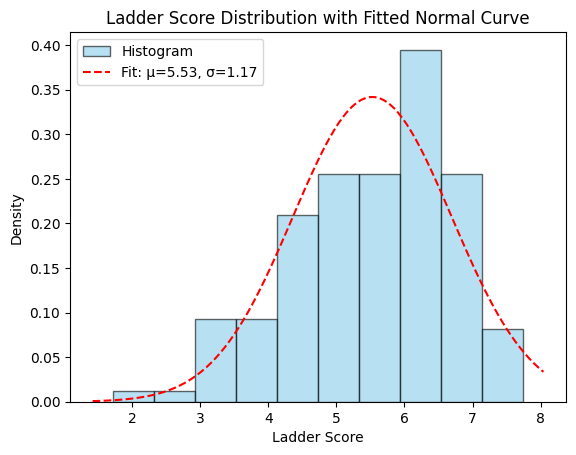

In [17]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

#get Ladder Scores
ladder_scores = df["Ladder score"]

#fit a normal distribution to the data
mu, std = norm.fit(ladder_scores)

#plot histogram
plt.hist(ladder_scores, bins=10, density=True, alpha=0.6, color="skyblue", edgecolor="black", label="Histogram")

#plot the PDF (probability density function)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, "r--", label=f"Fit: μ={mu:.2f}, σ={std:.2f}")

#add labels and legend
plt.title("Ladder Score Distribution with Fitted Normal Curve")
plt.xlabel("Ladder Score")
plt.ylabel("Density")
plt.legend()
plt.show()


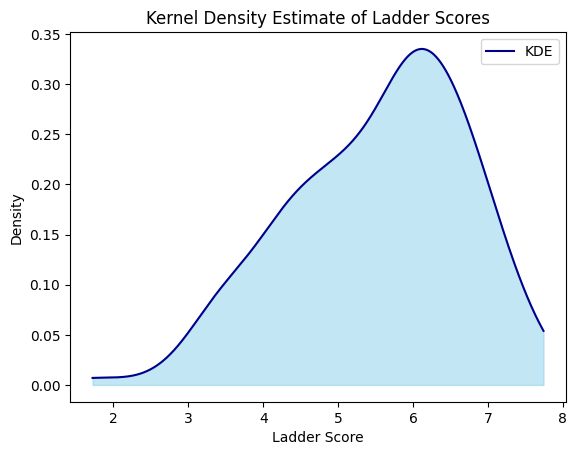

In [18]:
from scipy.stats import gaussian_kde

#Kernel Density Estimation
kde = gaussian_kde(ladder_scores)
x = np.linspace(ladder_scores.min(), ladder_scores.max(), 1000)
kde_values = kde(x)

#plot the KDE
plt.plot(x, kde_values, color="darkblue", label="KDE")
plt.fill_between(x, kde_values, color="skyblue", alpha=0.5)
plt.title("Kernel Density Estimate of Ladder Scores")
plt.xlabel("Ladder Score")
plt.ylabel("Density")
plt.legend()
plt.show()


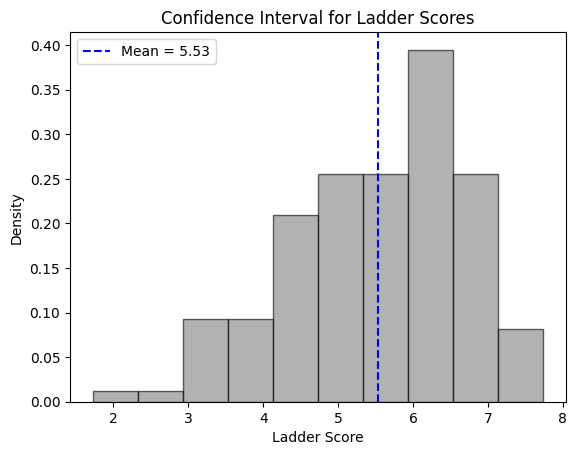

In [21]:
from scipy.stats import sem, t

#calculate statistics
mean = np.mean(ladder_scores)
std_err = sem(ladder_scores)
confidence = 0.95
h = std_err * t.ppf((1 + confidence) / 2, len(ladder_scores) - 1)

#plot mean and confidence interval
plt.axvline(mean, color="blue", linestyle="--", label=f"Mean = {mean:.2f}")
# plt.axvspan(mean - h, mean + h, color="lightblue", alpha=0.5, label="Interval")
plt.hist(ladder_scores, bins=10, density=True, alpha=0.6, color="gray", edgecolor="black")
plt.title("Confidence Interval for Ladder Scores")
plt.xlabel("Ladder Score")
plt.ylabel("Density")
plt.legend()
plt.show()


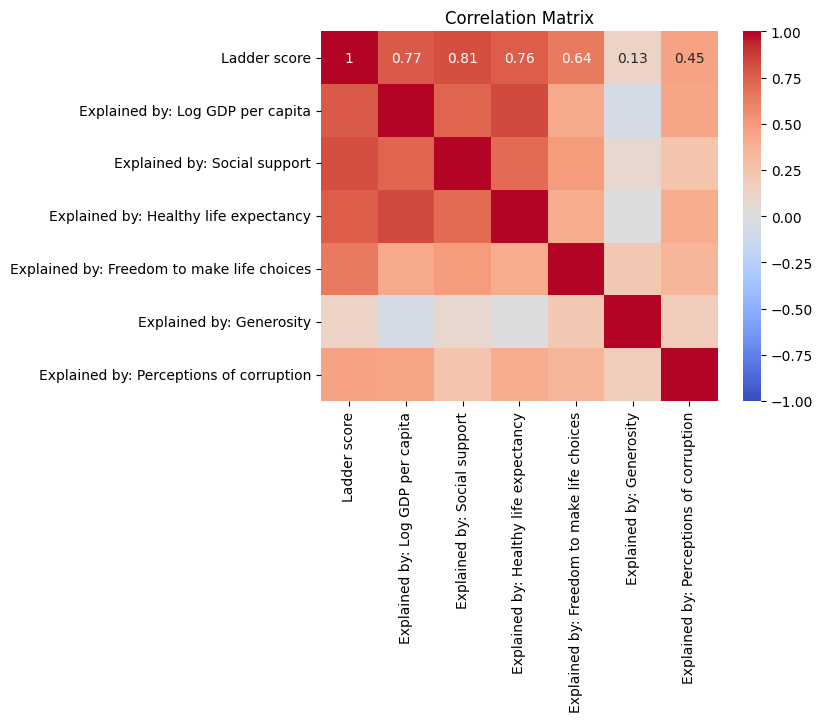

Pearson Correlation: 0.77, p-value: 0.0000


In [22]:
# from scipy.stats import pearsonr
# import seaborn as sns

# # relevant columns
# factors = [
#     "Ladder score",
#     "Explained by: Log GDP per capita",
#     "Explained by: Social support",
#     "Explained by: Healthy life expectancy",
#     "Explained by: Freedom to make life choices",
#     "Explained by: Generosity",
#     "Explained by: Perceptions of corruption"
# ]

# # Compute correlation matrix
# correlation_matrix = df[factors].corr()

# # Heatmap for correlation
# sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
# plt.title("Correlation Matrix")
# plt.show()

# # Example: Test significance of correlation between Ladder Score and Log GDP per capita
# corr, p_value = pearsonr(df["Ladder score"], df["Explained by: Log GDP per capita"])
# print(f"Pearson Correlation: {corr:.2f}, p-value: {p_value:.4f}")


import numpy as np

#select relevant columns
factors = [
    "Ladder score",
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption"
]

#drop rows with NaNs or infinite values
cleaned_data = df[factors].replace([np.inf, -np.inf], np.nan).dropna()

#compute correlation matrix
correlation_matrix = cleaned_data.corr()

#heatmap for correlation
import seaborn as sns
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

#Example: Test significance of correlation between Ladder Score and Log GDP per capita
from scipy.stats import pearsonr
corr, p_value = pearsonr(
    cleaned_data["Ladder score"], 
    cleaned_data["Explained by: Log GDP per capita"]
)
print(f"Pearson Correlation: {corr:.2f}, p-value: {p_value:.4f}")


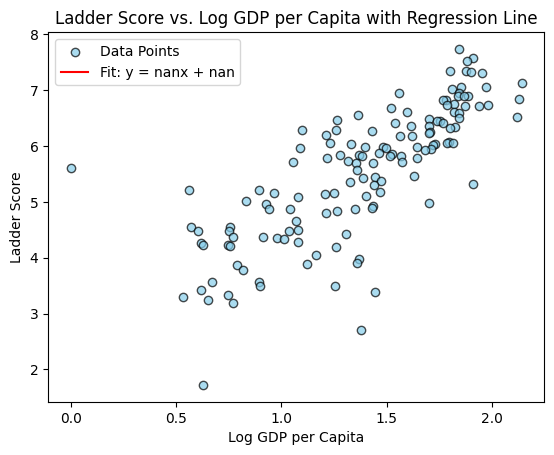

In [24]:
from scipy.stats import linregress

#linear regression
x = df["Explained by: Log GDP per capita"]
y = df["Ladder score"]
slope, intercept, r_value, p_value, std_err = linregress(x, y)

#scatter and regression line
plt.scatter(x, y, color="skyblue", edgecolor="black", alpha=0.7, label="Data Points")
plt.plot(x, slope * x + intercept, color="red", label=f"Fit: y = {slope:.2f}x + {intercept:.2f}")
plt.title("Ladder Score vs. Log GDP per Capita with Regression Line")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Ladder Score")
plt.legend()
plt.show()

# Print regression statistics
# print(f"Slope: {slope:.2f}, Intercept: {intercept:.2f}, R-squared: {r_value**2:.2f}, p-value: {p_value:.4f}")


## Statsmodel

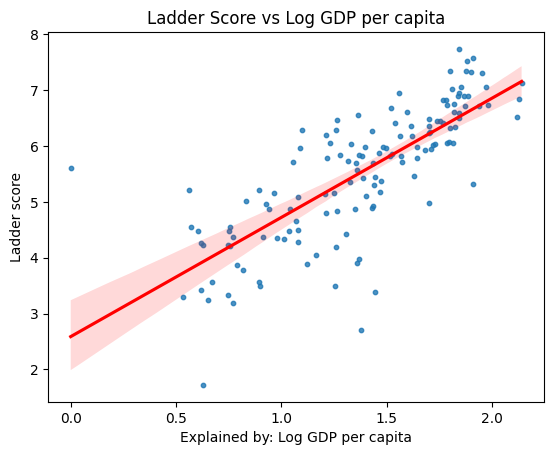

In [26]:
#scatter plot with regression equation
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x='Explained by: Log GDP per capita', y='Ladder score', data=df, scatter_kws={'s': 10}, line_kws={'color': 'red'})
plt.title('Ladder Score vs Log GDP per capita')
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\graphics\regressionplots.py:430: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fig = abline_plot(0, fitted_line.params[0], color='k', ax=ax)


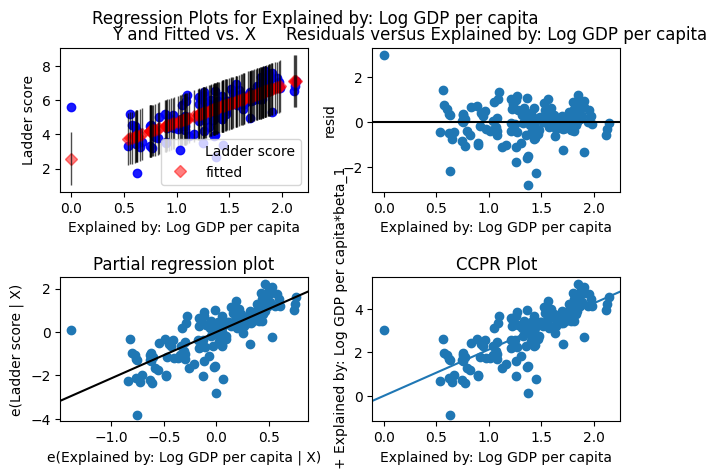

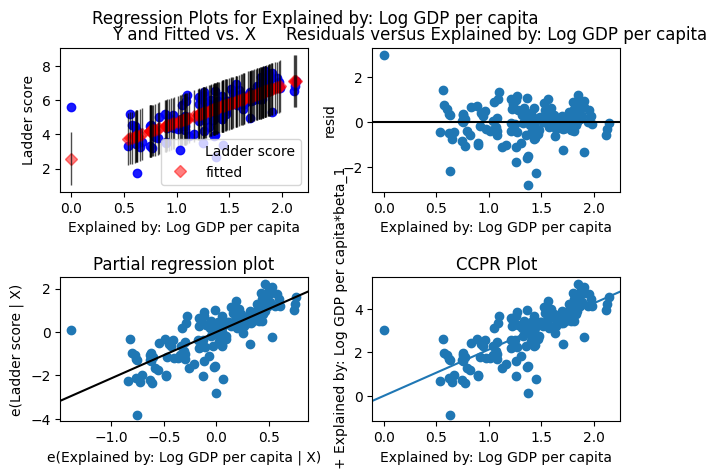

In [27]:
#drop rows with NaN or infinite values
df_clean = df.replace([np.inf, -np.inf], np.nan).dropna()

#scatter plot of Ladder Score vs. Log GDP per Capita
sm.graphics.plot_regress_exog(sm.OLS(df_clean['Ladder score'], sm.add_constant(df_clean['Explained by: Log GDP per capita'])).fit(), 1)